# Align OpenStreetMap to the nuScenes scenario region

nuScenes maps have a known geo-reference (lat/lon of each map origin), so the
local (x, y) region of a scenario can be projected to WGS84 and matched with
**OpenStreetMap**. For each scenario this notebook:

1. reads the scenario sidecar (`patch`, `origin`, `ego_trajectory_local`, `map`),
2. projects the region + ego trajectory to lat/lon,
3. fetches OSM roads + buildings for that bbox (Overpass API, stdlib only),
4. plots OSM with the nuScenes ego trajectory (red), lanes (blue), and the real
   **OSM traffic-signal locations** (yellow markers) overlaid,
5. saves the aligned figure to `output/osm_aligned/<scene>.png`.

The traffic-signal count/positions match what `convert_nuscenes_to_xodr.py
--traffic-lights --osm-signals` uses to place the correct number of lights.

Run in the **`nusc2xodr`** kernel. Needs internet (Overpass).


In [21]:
import os
import glob
import json
import math
import time
import urllib.request
import urllib.parse
import matplotlib.pyplot as plt

OUTDIR   = r"D:/research/nuscenes_carla/nuscenes2xodr/output"
DATAROOT = r"D:/research/nuscenes_carla/v1.0-mini"     # for NuScenesMap (lanes)
OUT_DIR  = os.path.join(OUTDIR, "osm_aligned")

# SCENE      = "scene-0061"   # a scene name, or None = every scenario sidecar found
SCENE      = None           # a scene name, or None = every scenario sidecar found
PAD        = 0.0012         # degrees of padding around the region bbox
SHOW_LANES = True           # overlay nuScenes lane centerlines (blue)

# nuScenes map origins (lat, lon) -- published reference coordinates
REF = {
    "boston-seaport":            [42.336849169438615, -71.05785369873047],
    "singapore-onenorth":        [1.2882100868743724, 103.78475189208984],
    "singapore-hollandvillage":  [1.2993652317780957, 103.78217697143555],
    "singapore-queenstown":      [1.2782562240223188, 103.76741409301758],
}
EARTH_R = 6378137.0
OVERPASS = ["https://overpass-api.de/api/interpreter",
            "https://overpass.kumi.systems/api/interpreter",
            "https://maps.mail.ru/osm/tools/overpass/api/interpreter"]


In [22]:
def local2global(loc, x, y):
    """nuScenes local metres (x=east, y=north) -> (lat, lon)."""
    la, lo = REF[loc]
    lat = la + (y / EARTH_R) * (180.0 / math.pi)
    lon = lo + (x / (EARTH_R * math.cos(math.radians(la)))) * (180.0 / math.pi)
    return lat, lon


def fetch_osm(s, w, n, e):
    """Fetch highways + buildings in a lat/lon bbox via Overpass (with mirrors)."""
    q = ('[out:json][timeout:60];'
         '(way["highway"](%f,%f,%f,%f);'
         ' way["building"](%f,%f,%f,%f);'
         ' node["highway"="traffic_signals"](%f,%f,%f,%f););out geom;'
         % (s, w, n, e, s, w, n, e, s, w, n, e))
    data = urllib.parse.urlencode({"data": q}).encode()
    for url in OVERPASS:
        for attempt in range(2):
            try:
                req = urllib.request.Request(
                    url, data=data, headers={"User-Agent": "nuscenes-osm/1.0"})
                raw = urllib.request.urlopen(req, timeout=90).read().decode()
                return json.loads(raw).get("elements", [])
            except Exception as ex:
                print("  overpass retry (%s): %s" % (url.split("/")[2],
                                                     repr(ex)[:60]))
                time.sleep(3)
    print("  OSM fetch failed for this bbox.")
    return []


def load_sidecars():
    """Map scene-name -> sidecar dict for every *_meta.json in the output dir."""
    out = {}
    for p in glob.glob(os.path.join(OUTDIR, "*_meta.json")):
        try:
            m = json.load(open(p))
            out[m["scene"]] = m
        except Exception:
            pass
    return out


sidecars = load_sidecars()
print("scenarios with sidecars:", ", ".join(sorted(sidecars)))


scenarios with sidecars: scene-0061, scene-0103, scene-0553, scene-0655, scene-0757, scene-0796, scene-0916, scene-1077, scene-1094, scene-1100


In [23]:
# nuScenes map (only needed for the blue lane overlay); cached per location
_nmap_cache = {}


def get_lanes_latlon(loc, patch):
    from nuscenes.map_expansion.map_api import NuScenesMap
    from nuscenes.map_expansion import arcline_path_utils
    if loc not in _nmap_cache:
        _nmap_cache[loc] = NuScenesMap(dataroot=DATAROOT, map_name=loc)
    nmap = _nmap_cache[loc]
    box = (patch["x_min"], patch["y_min"], patch["x_max"], patch["y_max"])
    recs = nmap.get_records_in_patch(box, ["lane", "lane_connector"],
                                     mode="intersect")
    polylines = []
    for tok in recs["lane"] + recs["lane_connector"]:
        try:
            pts = arcline_path_utils.discretize_lane(
                nmap.get_arcline_path(tok), resolution_meters=1.0)
        except Exception:
            continue
        polylines.append([local2global(loc, p[0], p[1]) for p in pts])
    return polylines


def build_scene_osm(scene_name, show_lanes=SHOW_LANES, save=True):
    m = sidecars.get(scene_name)
    if m is None:
        print("No sidecar for", scene_name); return
    loc = m["map"]
    if loc not in REF:
        print("No reference coords for", loc); return
    ox, oy = m["origin"]["x"], m["origin"]["y"]
    pt = m["patch"]
    corners = [(pt["x_min"], pt["y_min"]), (pt["x_max"], pt["y_max"])]
    llc = [local2global(loc, x, y) for x, y in corners]
    lats = [a for a, b in llc]
    lons = [b for a, b in llc]
    s, w = min(lats) - PAD, min(lons) - PAD
    n, e = max(lats) + PAD, max(lons) + PAD
    els = fetch_osm(s, w, n, e)

    fig, ax = plt.subplots(figsize=(9, 9))
    signals = []
    for el in els:
        if el.get("type") == "node":                       # traffic signal
            if el.get("tags", {}).get("highway") == "traffic_signals":
                signals.append((el["lat"], el["lon"]))
            continue
        g = el.get("geometry")
        if not g:
            continue
        xs = [p["lon"] for p in g]
        ys = [p["lat"] for p in g]
        if el.get("tags", {}).get("building"):
            ax.fill(xs, ys, color="0.80", ec="0.55", lw=0.3, zorder=1)
        else:
            ax.plot(xs, ys, color="0.45", lw=1.0, zorder=2)

    if show_lanes:
        for i, pl in enumerate(get_lanes_latlon(loc, pt)):
            ax.plot([b for a, b in pl], [a for a, b in pl], color="royalblue",
                    lw=1.2, alpha=0.8, zorder=3,
                    label="nuScenes lanes" if i == 0 else None)

    ego = [local2global(loc, p["x"] + ox, p["y"] + oy)
           for p in m["ego_trajectory_local"]]
    ax.plot([b for a, b in ego], [a for a, b in ego], color="red", lw=2.5,
            zorder=5, label="nuScenes ego")
    ax.scatter([b for a, b in ego], [a for a, b in ego], color="red", s=12,
               zorder=6)

    if signals:                                            # OSM traffic signals
        ax.scatter([lo for la, lo in signals], [la for la, lo in signals],
                   marker="o", s=110, facecolor="yellow", edgecolor="black",
                   linewidths=1.3, zorder=8,
                   label="OSM traffic signals (%d)" % len(signals))

    ax.set_aspect(1.0 / math.cos(math.radians(sum(lats) / len(lats))))
    ax.set_xlim(w, e); ax.set_ylim(s, n)
    ax.set_title("%s (%s) - OSM aligned with nuScenes" % (scene_name, loc))
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.legend(loc="upper right")
    if save:
        os.makedirs(OUT_DIR, exist_ok=True)
        out = os.path.join(OUT_DIR, "%s.png" % scene_name)
        fig.savefig(out, dpi=110, bbox_inches="tight")
        print("%s: %d OSM ways -> %s" % (scene_name, len(els), out))
    return fig


In [24]:
# process the chosen scene, or all scenarios that have a sidecar
targets = [SCENE] if SCENE else sorted(sidecars)
for sc in targets:
    build_scene_osm(sc)
    plt.close("all")
print("done ->", OUT_DIR)


scene-0061: 259 OSM ways -> D:/research/nuscenes_carla/nuscenes2xodr/output\osm_aligned\scene-0061.png
  overpass retry (overpass-api.de): <HTTPError 504: 'Gateway Timeout'>
scene-0103: 318 OSM ways -> D:/research/nuscenes_carla/nuscenes2xodr/output\osm_aligned\scene-0103.png
  overpass retry (overpass-api.de): <HTTPError 429: 'Too Many Requests'>
scene-0553: 253 OSM ways -> D:/research/nuscenes_carla/nuscenes2xodr/output\osm_aligned\scene-0553.png
scene-0655: 168 OSM ways -> D:/research/nuscenes_carla/nuscenes2xodr/output\osm_aligned\scene-0655.png
scene-0757: 259 OSM ways -> D:/research/nuscenes_carla/nuscenes2xodr/output\osm_aligned\scene-0757.png
  overpass retry (overpass-api.de): <HTTPError 429: 'Too Many Requests'>
scene-0796: 254 OSM ways -> D:/research/nuscenes_carla/nuscenes2xodr/output\osm_aligned\scene-0796.png
scene-0916: 334 OSM ways -> D:/research/nuscenes_carla/nuscenes2xodr/output\osm_aligned\scene-0916.png
scene-1077: 387 OSM ways -> D:/research/nuscenes_carla/nuscene

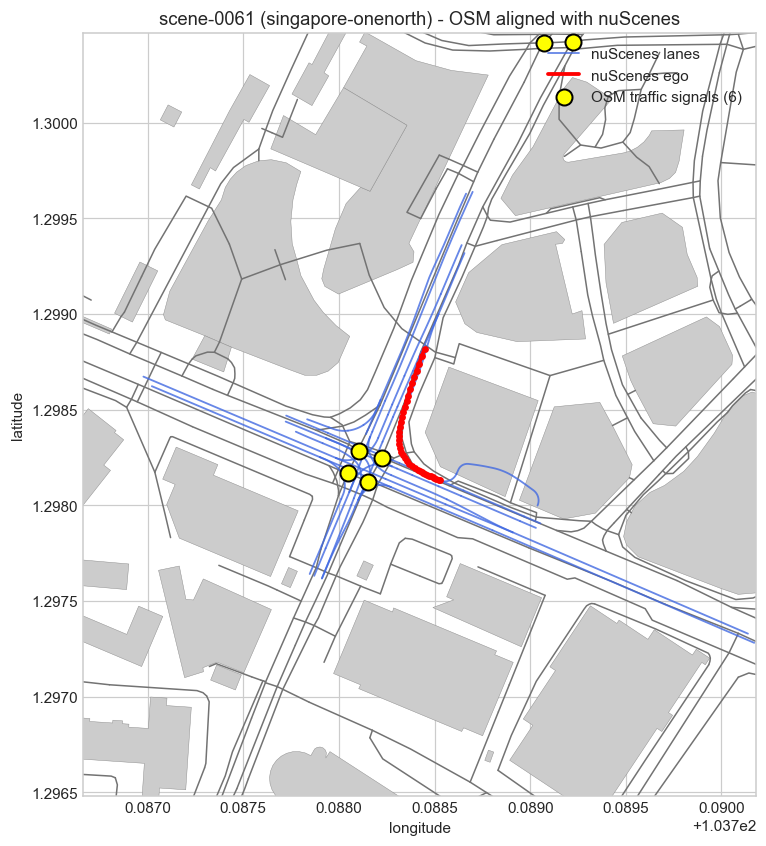

In [25]:
# preview one inline
from IPython.display import Image as IPImage, display
name = SCENE or (sorted(sidecars)[0] if sidecars else None)
if name:
    p = os.path.join(OUT_DIR, "%s.png" % name)
    if os.path.exists(p):
        display(IPImage(filename=p))
